# Movie Rating Predictor v2

In this project, I build a machine learning model to classify whether a movie is highly rated or not using features such as runtime, votes, metascore, genre, and more.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("data/movies_data_cleaned.csv")

In [3]:
df.head()

,Series_Title,Released_Year,Certificate,Runtime_Minutes,Genre,Subgenre,Subgenre 1,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Gross_Millions
0,The Shawshank Redemption,1994.0,A,142,Drama,Unknown,Unkown,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0,28.341469
1,The Godfather,1972.0,A,175,Crime,Drama,Unkown,9.2,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0,134.966411
2,The Dark Knight,2008.0,UA,152,Action,Crime,Drama,9.0,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0,534.858444
3,The Godfather: Part II,1974.0,A,202,Crime,Drama,Unkown,9.0,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0,57.300000
4,12 Angry Men,1957.0,U,96,Crime,Drama,Unkown,9.0,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0,4.360000


In [4]:
df.shape

(1000, 17)

In [5]:
df.columns

Index(['Series_Title', 'Released_Year', 'Certificate', 'Runtime_Minutes',
       'Genre', 'Subgenre', 'Subgenre 1', 'IMDB_Rating', 'Meta_score',
       'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross',
       'Gross_Millions'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Series_Title     1000 non-null   str    
 1   Released_Year    999 non-null    float64
 2   Certificate      1000 non-null   str    
 3   Runtime_Minutes  1000 non-null   int64  
 4   Genre            1000 non-null   str    
 5   Subgenre         1000 non-null   str    
 6   Subgenre 1       1000 non-null   str    
 7   IMDB_Rating      1000 non-null   float64
 8   Meta_score       843 non-null    float64
 9   Director         1000 non-null   str    
 10  Star1            1000 non-null   str    
 11  Star2            1000 non-null   str    
 12  Star3            1000 non-null   str    
 13  Star4            1000 non-null   str    
 14  No_of_Votes      1000 non-null   int64  
 15  Gross            831 non-null    float64
 16  Gross_Millions   831 non-null    float64
dtypes: float64(5), int64(2), s

In [7]:
df.isna().sum()

Series_Title         0
Released_Year        1
Certificate          0
Runtime_Minutes      0
Genre                0
Subgenre             0
Subgenre 1           0
IMDB_Rating          0
Meta_score         157
Director             0
Star1                0
Star2                0
Star3                0
Star4                0
No_of_Votes          0
Gross              169
Gross_Millions     169
dtype: int64

In [8]:
df['Target'] = (df['IMDB_Rating'] >= 8.0).astype(int)

In [10]:
df[["Series_Title", "IMDB_Rating", "Target"]].head()

,Series_Title,IMDB_Rating,Target
0,The Shawshank Redemption,9.3,1
1,The Godfather,9.2,1
2,The Dark Knight,9.0,1
3,The Godfather: Part II,9.0,1
4,12 Angry Men,9.0,1


In [11]:
df["Target"].value_counts()

Target
0    537
1    463
Name: count, dtype: int64

In [12]:
df["Target"].value_counts(normalize=True)

Target
0    0.537
1    0.463
Name: proportion, dtype: float64

I converted IMDb ratings into a binary classification problem, where movies with rating ≥ 8 are considered high-rated

## Select Features

In [13]:
features = ['Runtime_Minutes', 'No_of_Votes', 'Released_Year', 'Meta_score', 'Certificate','Genre', 'Director', 'Star1']

X = df[features]
y = df["Target"]

In [15]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Runtime_Minutes  1000 non-null   int64  
 1   No_of_Votes      1000 non-null   int64  
 2   Released_Year    999 non-null    float64
 3   Meta_score       843 non-null    float64
 4   Certificate      1000 non-null   str    
 5   Genre            1000 non-null   str    
 6   Director         1000 non-null   str    
 7   Star1            1000 non-null   str    
dtypes: float64(2), int64(2), str(4)
memory usage: 62.6 KB


In [16]:
X.isna().sum()

Runtime_Minutes      0
No_of_Votes          0
Released_Year        1
Meta_score         157
Certificate          0
Genre                0
Director             0
Star1                0
dtype: int64

In [17]:
X_clean = X.copy()

In [18]:
numerical_cols = ["Runtime_Minutes", "No_of_Votes", "Released_Year", "Meta_score"]

for col in numerical_cols:
    X_clean[col] = X_clean[col].fillna(X_clean[col].median())

In [19]:
categorical_cols = ["Certificate", "Genre", "Director", "Star1"]

for col in categorical_cols:
    X_clean[col] = X_clean[col].fillna("Unknown")

In [20]:
X_clean.isna().sum()

Runtime_Minutes    0
No_of_Votes        0
Released_Year      0
Meta_score         0
Certificate        0
Genre              0
Director           0
Star1              0
dtype: int64

## Encode Data

In [21]:
X_encoded = pd.get_dummies(X_clean, drop_first=True)

In [22]:
X_encoded.head()

,Runtime_Minutes,No_of_Votes,Released_Year,Meta_score,Certificate_A,Certificate_Approved,Certificate_G,Certificate_GP,Certificate_PG,Certificate_PG-13,...,Star1_Yun-Fat Chow,Star1_Yves Montand,Star1_Yôji Matsuda,Star1_Zach Galifianakis,Star1_Zain Al Rafeea,Star1_Zbigniew Zamachowski,Star1_Zooey Deschanel,Star1_Çetin Tekindor,Star1_Éric Toledano,Star1_Ömer Faruk Sorak
0,142,2343110,1994.0,80.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,175,1620367,1972.0,100.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,152,2303232,2008.0,84.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,202,1129952,1974.0,90.0,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,96,689845,1957.0,96.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [23]:
X_encoded.shape

(1000, 1239)

In [24]:
X_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 1239 entries, Runtime_Minutes to Star1_Ömer Faruk Sorak
dtypes: bool(1235), float64(2), int64(2)
memory usage: 1.2 MB


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

## Train/Test Split

In [26]:
print(X_train.shape)
print(X_test.shape)

(800, 1239)
(200, 1239)


In [27]:
print(y_train.shape)
print(y_test.shape)

(800,)
(200,)


In [28]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Target
0    0.535
1    0.465
Name: proportion, dtype: float64
Target
0    0.545
1    0.455
Name: proportion, dtype: float64


## Train Models

### Logistic Regression

In [29]:
log_model = LogisticRegression(max_iter=1000)

In [30]:
log_model.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [31]:
y_pred_log = log_model.predict(X_test)

In [32]:
accuracy_score(y_test, y_pred_log)

0.685

In [33]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.685


In [34]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.69      0.75      0.72       109
           1       0.67      0.60      0.64        91

    accuracy                           0.69       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.68      0.69      0.68       200



In [35]:
print(confusion_matrix(y_test, y_pred_log))

[[82 27]
 [36 55]]


### Decision Tree

In [36]:
tree_model = DecisionTreeClassifier(random_state=42)

In [37]:
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [38]:
y_pred_tree = tree_model.predict(X_test)

In [39]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 0.595


In [40]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.61      0.71      0.66       109
           1       0.57      0.46      0.51        91

    accuracy                           0.59       200
   macro avg       0.59      0.58      0.58       200
weighted avg       0.59      0.59      0.59       200



In [41]:
print(confusion_matrix(y_test, y_pred_tree))

[[77 32]
 [49 42]]


### Random Forest

In [42]:
forest_model = RandomForestClassifier(random_state=42)

In [43]:
forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [44]:
y_pred_forest= forest_model.predict(X_test)

In [45]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_forest))

Random Forest Accuracy: 0.705


In [46]:
print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.70      0.81      0.75       109
           1       0.72      0.58      0.64        91

    accuracy                           0.70       200
   macro avg       0.71      0.69      0.70       200
weighted avg       0.71      0.70      0.70       200



In [47]:
print(confusion_matrix(y_test, y_pred_forest))

[[88 21]
 [38 53]]


## Evaluate Models

In [48]:
log_acc = accuracy_score(y_test, y_pred_log)
tree_acc = accuracy_score(y_test, y_pred_tree)
forest_acc = accuracy_score(y_test, y_pred_forest)

In [49]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [log_acc, tree_acc, forest_acc]
})

results

,Model,Accuracy
0,Logistic Regression,0.685
1,Decision Tree,0.595
2,Random Forest,0.705


In [50]:
results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.705
0,Logistic Regression,0.685
1,Decision Tree,0.595


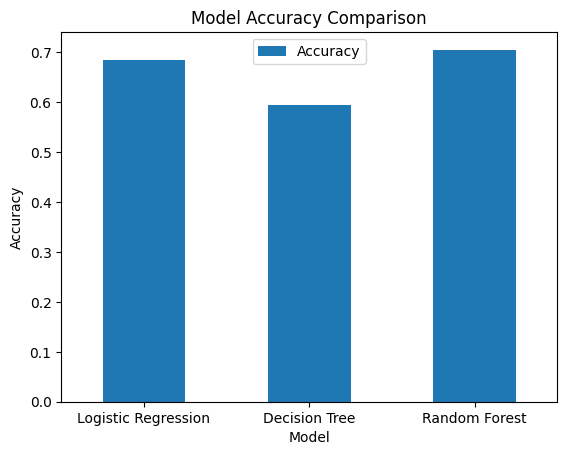

In [51]:
results.plot(x="Model", y="Accuracy", kind="bar")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

I compared Logistic Regression, Decision Tree, and Random Forest models using accuracy as the primary metric. Random Forest achieved the best performance, likely due to its ability to capture non-linear relationships and reduce overfitting through ensemble learning. Logistic Regression provided a strong baseline with interpretable results, while the Decision Tree showed signs of overfitting.

## Feature Importance

### Logistic Regression

In [53]:
log_coeff = pd.Series(log_model.coef_[0], index=X_encoded.columns)

In [54]:
log_coeff_sorted = log_coeff.sort_values()

In [55]:
log_coeff_sorted.head(10)

Certificate_PG-13           -1.376508
Director_Alfonso Cuarón     -1.321557
Director_David Fincher      -1.183785
Star1_Tom Hanks             -1.175402
Director_Howard Hawks       -1.172991
Director_Ang Lee            -1.136902
Star1_Tom Cruise            -1.039331
Director_Steven Spielberg   -0.997344
Star1_Daniel Radcliffe      -0.967441
Director_Fred Zinnemann     -0.882199
dtype: float64

In [56]:
log_coeff_sorted.tail(10)

Star1_James Stewart         1.001504
Director_Stanley Kubrick    1.013754
Director_Rajkumar Hirani    1.026942
Star1_Toshirô Mifune        1.029626
Genre_Mystery               1.080611
Star1_Akshay Kumar          1.158755
Director_Charles Chaplin    1.241101
Star1_Charles Chaplin       1.241101
Director_Akira Kurosawa     1.432312
Director_Ingmar Bergman     1.504368
dtype: float64

### Random Forest

In [57]:
forest_importance = pd.Series(
    forest_model.feature_importances_,
    index=X_encoded.columns
)

In [58]:
forest_importance_sorted = forest_importance.sort_values(ascending=False)

In [59]:
forest_importance_sorted.head(10)

No_of_Votes        0.131190
Runtime_Minutes    0.081345
Meta_score         0.065788
Released_Year      0.062532
Genre_Drama        0.009808
Certificate_R      0.009316
Genre_Comedy       0.007938
Certificate_A      0.007130
Certificate_U      0.006398
Certificate_UA     0.006254
dtype: float64

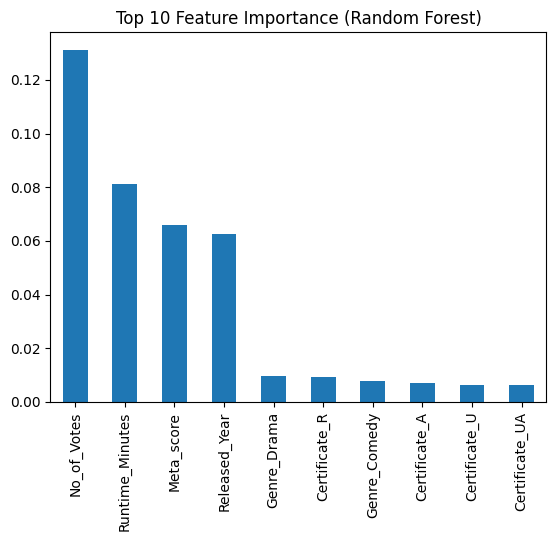

In [60]:
forest_importance_sorted.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importance (Random Forest)")
plt.show()

## Final Conclusion

In this project, I built a machine learning model to classify movies as high-rated or not using features such as runtime, number of votes, metascore, genre, certificate, director, and main actor.

I trained and compared three models: Logistic Regression, Decision Tree, and Random Forest. Logistic Regression served as a baseline model, while tree-based models were used to capture more complex relationships.

The results showed that Random Forest achieved the highest accuracy, suggesting that ensemble methods are effective for this problem. Logistic Regression also performed well, while Decision Tree showed signs of overfitting.

Feature importance analysis indicated that variables such as number of votes and metascore were among the most influential predictors, highlighting the importance of both audience popularity and critic evaluation.

One limitation of this dataset is that it contains only highly rated movies, which reduces variation in the target variable. Future improvements could include better feature engineering, grouping rare categories, and tuning model parameters.